In [8]:
import torch

file_path = "/mnt/abka03/Projects/xl-vlms/outputs/run_test_noidle/concept/snmf/combined_concept_snmf_raw.pth"
data1 = torch.load(file_path, map_location='cpu')
print(data1.keys())
print(data1['concepts'].shape)
print(data1['image_grounding_bboxes'])
print(data1['image_grounding_predictions'])
print(data1['text_grounding'])
print(data1['image_grounding_paths'])
print(data1['concept_names'])

dict_keys(['concepts', 'concept_names', 'activations', 'decomposition_method', 'text_grounding', 'image_grounding_paths', 'image_grounding_bboxes', 'image_grounding_masks', 'analysis_model', 'image_grounding_predictions'])
torch.Size([3, 3584])
[[[174, 104, 164, 164], [154, 220, 164, 164], [174, 170, 164, 164], [182, 117, 164, 164], [315, 70, 164, 164], [127, 113, 164, 164], [132, 26, 164, 164], [174, 136, 164, 164], [136, 220, 164, 164], [316, 162, 164, 164]], [[262, 115, 164, 164], [143, 51, 164, 164], [174, 14, 164, 164], [148, 72, 164, 164], [174, 101, 164, 164], [174, 10, 164, 164], [174, 25, 164, 164], [98, 64, 164, 164], [174, 86, 164, 164], [190, 130, 164, 164]], [[156, 80, 164, 164], [232, 120, 164, 164], [132, 84, 164, 164], [180, 106, 164, 164], [85, 188, 164, 164], [228, 0, 164, 164], [189, 111, 164, 164], [310, 134, 164, 164], [175, 0, 164, 164], [0, 72, 164, 164]]]
[['House', 'House', 'House', 'House', 'House', 'House', 'House', 'House', 'House', 'No house'], ['Mountain',

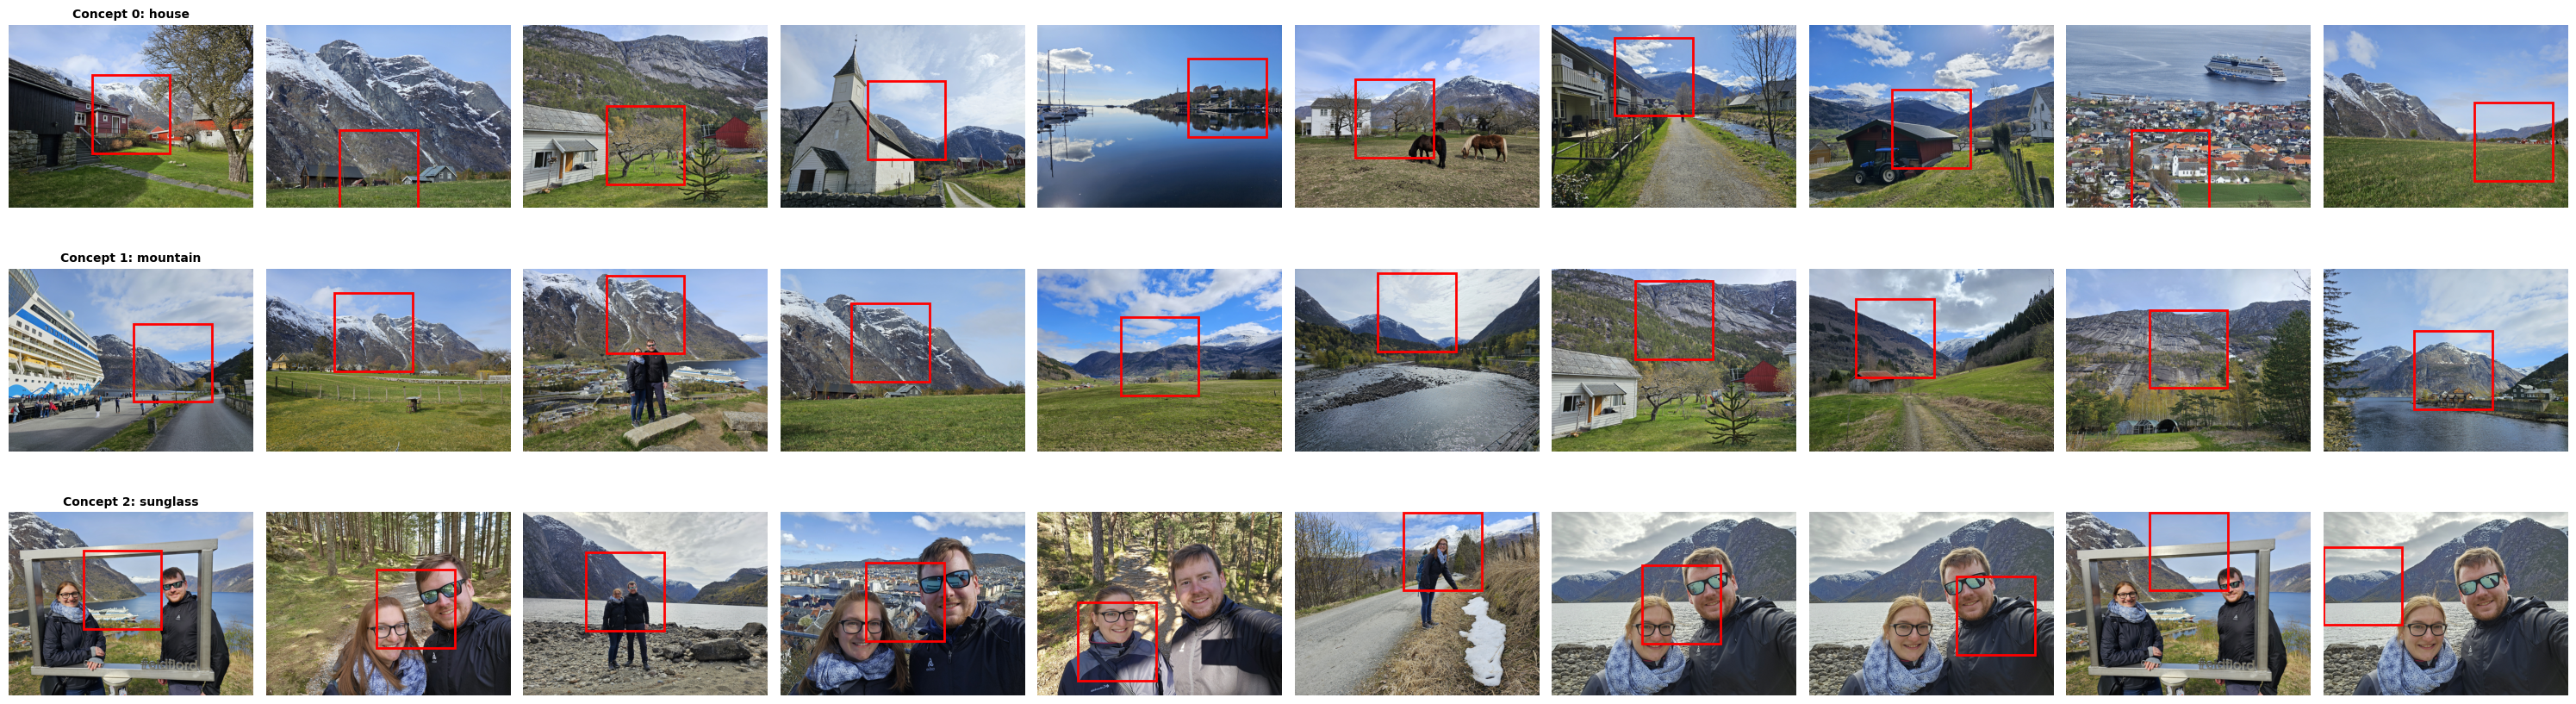

In [9]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.patches import Rectangle

# Expected keys in data1:
# - image_grounding_paths: [num_concepts][num_images]
# - image_grounding_bboxes: [num_concepts][num_images] with [x, y, w, h] in resized-image space
# - image_grounding_predictions: [num_concepts][num_images]
# - concept_names: [num_concepts][num_images] (often repeated concept label)

# Keep bbox/image coordinate space consistent with feature generation
IMAGE_SIZE_WIDTH = 512

paths_all = data1.get("image_grounding_paths", [])
bboxes_all = data1.get("image_grounding_bboxes", [])
preds_all = data1.get("image_grounding_predictions", [])
concept_names_all = data1.get("concept_names", [])

def _safe_get(arr, i, j, default=None):
    try:
        return arr[i][j]
    except Exception:
        return default

def _to_list_if_tensor(x):
    if hasattr(x, "detach") and hasattr(x, "cpu"):
        return x.detach().cpu().numpy().tolist()
    return x

def _resize_by_width(img, target_width):
    if target_width is None or int(target_width) <= 0:
        return img
    target_width = int(target_width)
    ow, oh = img.size
    if ow <= 0 or oh <= 0:
        return img
    if ow == target_width:
        return img
    scale = target_width / float(ow)
    nh = max(1, int(round(oh * scale)))
    resample = getattr(getattr(Image, "Resampling", Image), "LANCZOS", Image.BICUBIC)
    return img.resize((target_width, nh), resample=resample)

num_concepts = len(paths_all)
if num_concepts == 0:
    raise ValueError("No image_grounding_paths found in data1")

# Infer number of columns from first row; fallback to max across rows
num_cols = 0
for row in paths_all:
    if isinstance(row, list):
        num_cols = max(num_cols, len(row))
if num_cols == 0:
    raise ValueError("image_grounding_paths is empty or malformed")

fig_w = max(14, num_cols * 3.0)
fig_h = max(8, num_concepts * 3.0)
fig, axes = plt.subplots(num_concepts, num_cols, figsize=(fig_w, fig_h), squeeze=False)

for i in range(num_concepts):
    # Try to derive one concept label per row
    row_concept_name = ""
    if i < len(concept_names_all) and isinstance(concept_names_all[i], list) and len(concept_names_all[i]) > 0:
        row_concept_name = str(concept_names_all[i][0])

    for j in range(num_cols):
        ax = axes[i, j]
        ax.axis("off")

        img_path = _safe_get(paths_all, i, j, None)
        bbox = _to_list_if_tensor(_safe_get(bboxes_all, i, j, None))
        pred = _safe_get(preds_all, i, j, "")

        if not img_path or not isinstance(img_path, str) or not os.path.exists(img_path):
            ax.text(0.5, 0.5, "Missing image", ha="center", va="center", fontsize=9)
            continue

        try:
            img = Image.open(img_path).convert("RGB")
            # IMPORTANT: Resize first so bbox is drawn in the same coordinate space.
            img = _resize_by_width(img, IMAGE_SIZE_WIDTH)
            img_np = np.array(img)
            ax.imshow(img_np)

            # Draw bbox as [x, y, w, h] on resized image space
            if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                x, y, w, h = [float(v) for v in bbox]
                rect = Rectangle((x, y), w, h, linewidth=2.0, edgecolor="red", facecolor="none")
                ax.add_patch(rect)

            # Prediction below each image
            pred_text = str(pred)
            ax.set_xlabel(pred_text, fontsize=8, labelpad=4)

        except Exception as e:
            ax.text(0.5, 0.5, f"Error loading image\n{e}", ha="center", va="center", fontsize=8)

        # Put concept name as title on first column of each row
        if j == 0:
            title_text = f"Concept {i}: {row_concept_name}" if row_concept_name else f"Concept {i}"
            ax.set_title(title_text, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

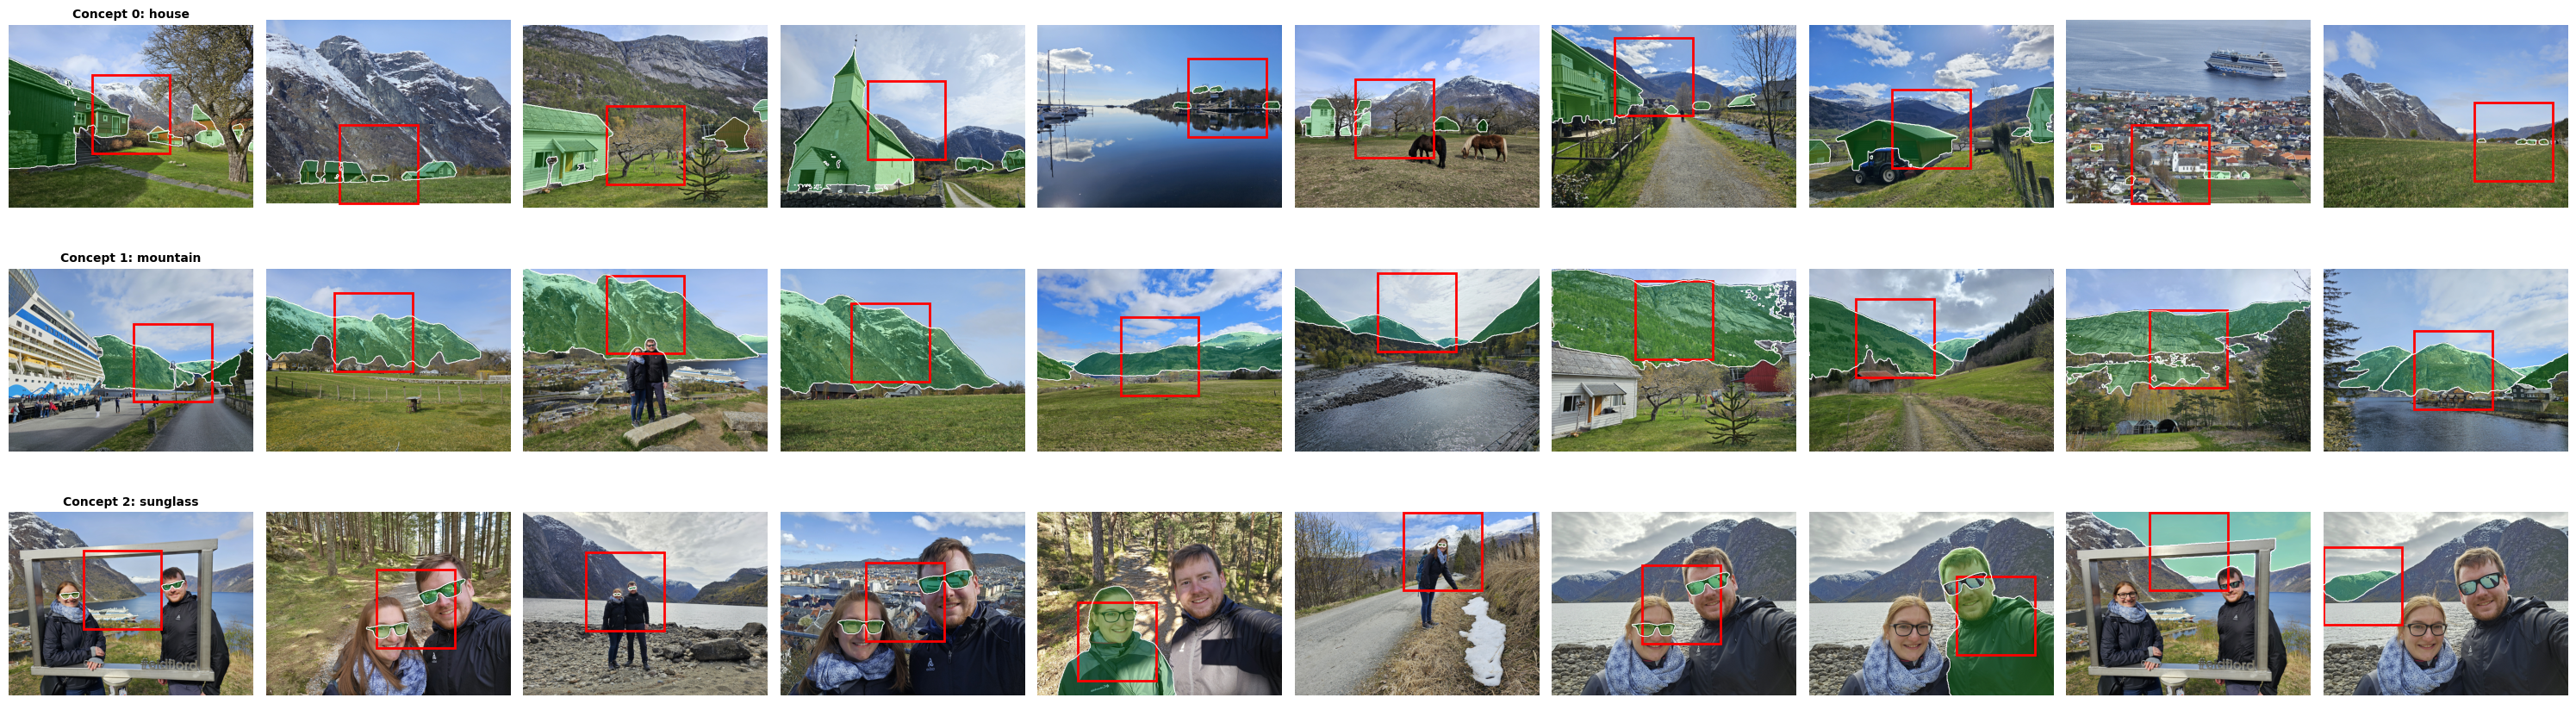

In [10]:
# Overlay RLE masks (if present) on each image — robust/debug version
# Ensure project root is on sys.path so `src` is importable in notebooks
import sys
from pathlib import Path
repo_root = Path.cwd().resolve()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / 'src').is_dir():
        repo_root = candidate
        break
repo_root = str(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
# Local imports used by this cell (safe even if run standalone)
import os
import traceback
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as _PILImage
from matplotlib.patches import Rectangle
from src.mask_utils import decode_mask_rle

# Defensive defaults
paths_all = data1.get('image_grounding_paths', []) if data1 is not None else []
bboxes_all = data1.get('image_grounding_bboxes', []) if data1 is not None else []
preds_all = data1.get('image_grounding_predictions', []) if data1 is not None else []
concept_names_all = data1.get('concept_names', []) if data1 is not None else []
masks_all = data1.get('image_grounding_masks', []) if data1 is not None else []


def _safe_get(arr, i, j, default=None):
    try:
        return arr[i][j]
    except Exception:
        return default


def _to_list_if_tensor(x):
    if hasattr(x, 'detach') and hasattr(x, 'cpu'):
        return x.detach().cpu().numpy().tolist()
    return x


def _resize_by_width(img, target_width):
    if target_width is None or int(target_width) <= 0:
        return img
    target_width = int(target_width)
    ow, oh = img.size
    if ow <= 0 or oh <= 0:
        return img
    if ow == target_width:
        return img
    scale = target_width / float(ow)
    nh = max(1, int(round(oh * scale)))
    resample = getattr(getattr(Image, 'Resampling', Image), 'LANCZOS', Image.BICUBIC)
    return img.resize((target_width, nh), resample=resample)


def _overlay_rle_on_axis(ax, rle, img):
    if rle is None:
        return
    try:
        # Accept either an RLE dict or already-decoded boolean mask
        if isinstance(rle, dict):
            mask = decode_mask_rle(rle)  # H, W bool
        else:
            arr = np.asarray(rle)
            mask = arr.astype(bool) if arr.ndim == 2 else None
        if mask is None:
            print('Warning: mask is None or not 2D')
            return
    except Exception as e:
        print('RLE decode failed:', type(e).__name__, e)
        traceback.print_exc()
        return
    # Resize mask to match displayed image width if necessary
    iw, ih = img.size
    target_w = IMAGE_SIZE_WIDTH if 'IMAGE_SIZE_WIDTH' in globals() else None
    if target_w and target_w != iw:
        try:
            new_h = max(1, int(round(ih * (target_w / float(iw)))))
            mask = np.array(_PILImage.fromarray(mask.astype(np.uint8) * 255).resize((target_w, new_h), _PILImage.NEAREST)) > 127
        except Exception as e:
            print('Mask resize failed:', e)
            return
    # Light mask overlay that keeps the original image visible.
    try:
        mask_f = mask.astype(float)
        if np.any(mask_f > 0):
            overlay = np.zeros((*mask_f.shape, 4), dtype=float)
            overlay[..., 1] = mask_f  # green channel
            overlay[..., 3] = mask_f * 0.18  # low alpha to preserve image colors
            ax.imshow(overlay, interpolation='nearest')
            ax.contour(mask_f, levels=[0.5], colors=['white'], linewidths=0.8, alpha=0.9)
    except Exception as e:
        print('Overlay render failed:', e)
        traceback.print_exc()


# Recreate the figure with overlays (reuse layout from previous cell)
# Defensive: compute counts and cap total cells to avoid OOMs
num_concepts = len(paths_all) if isinstance(paths_all, list) else 0
num_cols = 0
for row in paths_all:
    if isinstance(row, list):
        num_cols = max(num_cols, len(row))
# Cap total cells to a safe maximum (configurable via env var)
max_cells = int(os.environ.get('MAX_DISPLAY_CELLS', '200'))
total_cells = max(1, num_concepts * max(1, num_cols))
if total_cells > max_cells:
    # Reduce rows to fit within max_cells while keeping columns
    max_rows = max(1, max_cells // max(1, num_cols))
    print(f'Warning: grid too large ({total_cells} cells). Limiting to {max_rows} rows.')
    num_concepts_to_show = max_rows
else:
    num_concepts_to_show = num_concepts
num_cols_to_show = num_cols
if num_concepts_to_show <= 0 or num_cols_to_show <= 0:
    print('Nothing to display: no concepts or columns detected')
else:
    try:
        fig_w = max(14, num_cols_to_show * 3.0)
        fig_h = max(8, num_concepts_to_show * 3.0)
        fig, axes = plt.subplots(num_concepts_to_show, num_cols_to_show, figsize=(fig_w, fig_h), squeeze=False)
        for i in range(num_concepts_to_show):
            row_concept_name = ''
            if i < len(concept_names_all) and isinstance(concept_names_all[i], list) and len(concept_names_all[i]) > 0:
                row_concept_name = str(concept_names_all[i][0])
            for j in range(num_cols_to_show):
                ax = axes[i, j]
                ax.axis('off')
                img_path = _safe_get(paths_all, i, j, None)
                bbox = _to_list_if_tensor(_safe_get(bboxes_all, i, j, None))
                pred = _safe_get(preds_all, i, j, '')
                mask_rle = _safe_get(masks_all, i, j, None)
                if not img_path or not isinstance(img_path, str) or not os.path.exists(img_path):
                    ax.text(0.5, 0.5, 'Missing image', ha='center', va='center', fontsize=9)
                    continue
                try:
                    img = _PILImage.open(img_path).convert('RGB')
                    img = _resize_by_width(img, IMAGE_SIZE_WIDTH)
                    img_np = np.array(img)
                    ax.imshow(img_np)
                    if isinstance(bbox, (list, tuple)) and len(bbox) == 4:
                        x, y, w, h = [float(v) for v in bbox]
                        rect = Rectangle((x, y), w, h, linewidth=2.0, edgecolor='red', facecolor='none')
                        ax.add_patch(rect)
                    if mask_rle is not None:
                        _overlay_rle_on_axis(ax, mask_rle, img)
                    pred_text = str(pred)
                    ax.set_xlabel(pred_text, fontsize=8, labelpad=4)
                except Exception as e:
                    ax.text(0.5, 0.5, f'Error loading image\n{e}', ha='center', va='center', fontsize=8)
                if j == 0:
                    title_text = f'Concept {i}: {row_concept_name}' if row_concept_name else f'Concept {i}'
                    ax.set_title(title_text, fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print('Plotting failed:', type(e).__name__, e)
        traceback.print_exc()
